## IMPORTS

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.cluster import KMeans
import numpy as np
from stop_words import get_stop_words
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV

15
Inertie correspondante : 915.0304942626937
Meilleur nombre de clusters :
{'n_clusters': 6}
Meilleur silhouette score :
0.011459860841927483


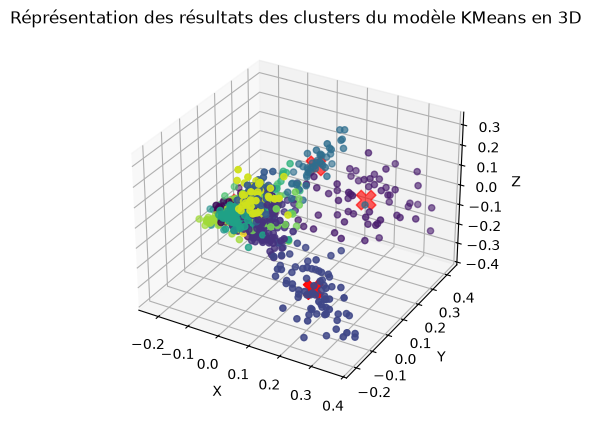

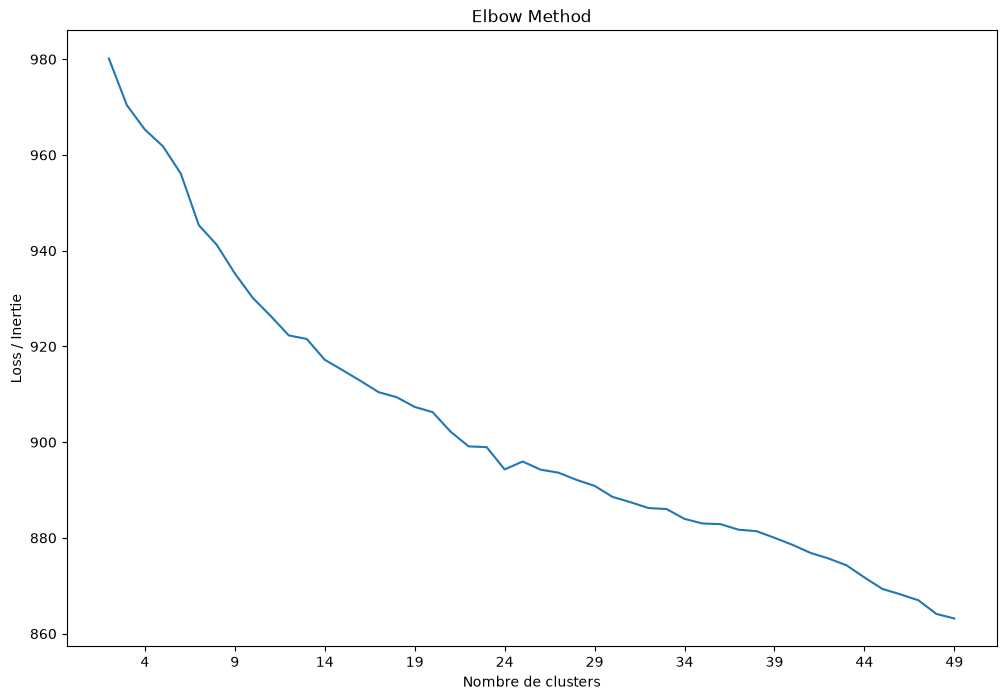

In [ ]:
df = pd.read_csv("../../Student_Clean.csv")

#Récupère les textes et remplace les NA par des ""
texts = df["Temoignage"].fillna("")

#Créer mon TF-IDF (Terme frequency invert document frequency) en retirant les stop_words
vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(texts) #Transforme les mots en valeurs et regarde si chaque phrase possède ces mots pour leurs donner un score

#Test chaque nombre de clusters entre 2 et 50 puis ajoute les score dans un dico et enfin print le meilleur score de ce dico afin de connaître la meilleur valeur pour le nombre de clusters
scores = {}
inertias = {}
for n in range(2, 50):
    kmeans = KMeans(
        n_clusters=n,
        random_state=0,
        n_init="auto", #KMeans peut essayer plusieurs initialisations différentes afin d'éviter de tomber sur une mauvaise configuration de départ, "auto" demande à sklearn de choisir automatiquement le comportement
    )
    Y = kmeans.fit_predict(X)
    inertias[f"{n}"] = kmeans.inertia_
    score = silhouette_score(X, Y) # Regarde si les points sont proches de leurs centroïdes et si ils sont éloignée des autres clusters puis donne un score en fonction du résultat
    scores[f"{n}"] = score

highest_key = max(scores, key=scores.get)

print(highest_key)
print("Inertie correspondante :", inertias[highest_key])

# ================================================================= #

# Créer mon KMeans avec le meilleur nombre de clusters

kmeans = KMeans(
        n_clusters=int(highest_key),
        random_state=0,
        n_init="auto" #KMeans peut essayer plusieurs initialisations différentes afin d'éviter de tomber sur une mauvaise configuration de départ, "auto" demande à sklearn de choisir automatiquement le comportement
    )

#Entraîne le modèle sur nos témoignages d'entrée médicale à l'hôpital
Y = kmeans.fit_predict(X)

#Transforme notre matrice sparse du TF-IDF en matrice numpy classique 
X_dense = X.toarray()

#Créer la figure 
fig = plt.figure()

#Créer l'axe en 3D 
axe = fig.add_subplot(111, projection="3d")

#Le TF-IDF à potentiellement plein de dimensions genre si on lui donne 10000 mots il peut potentiellement avoir 10000 dimensions PCA fais en sorte de ne prendre qu'un représentation avec le nombre de dimensions donné
pca = PCA(n_components=3)

#Transforme le vecteur de mes textes en vecteur 3D
points_3d = pca.fit_transform(X_dense)

#Transforme le vecteur des centroïdes de mes clusters en vecteur 3D
centroïdes_3d = pca.transform(kmeans.cluster_centers_)

#Affiche tout mes points en 3D
axe.scatter(
    points_3d[:, 0],
    points_3d[:, 1],
    points_3d[:, 2],
    c=Y
)

#Affiche tout mes centroïdes en 3D
axe.scatter(
    centroïdes_3d[:, 0],
    centroïdes_3d[:, 1],
    centroïdes_3d[:, 2],
    marker="X",
    s=200,
    c="red"
)

#Nomme les axes
plt.title('Réprésentation des résultats des clusters du modèle KMeans en 3D')
axe.set_xlabel("X")
axe.set_ylabel("Y")
axe.set_zlabel("Z")

#Affiche le graphique
plt.show()


fig = plt.figure(figsize=(12, 8))
plt.xticks(range(2, 51, 5))
plt.plot(inertias.keys(), inertias.values())
plt.xlabel("Nombre de clusters")
plt.ylabel("Loss / Inertie")
plt.title("Elbow Method")
plt.show()

